### General Configuration

In [1]:
# general imports
import glob
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings

warnings.filterwarnings('ignore')

In [2]:
############### General Configuration #############


# ── QJRMS / Wiley figure standard ────────────────────────────────────────────
MM     = 1/25.4
COL_W  = 84 * MM     # single-column width  [in]  (~3.31")
PAGE_W = 174 * MM    # full-page width      [in]  (~6.85")

plt.rcParams.update({
    'figure.dpi'      : 100,     # screen preview
    'savefig.dpi'     : 600,     # raster export
    'savefig.bbox'    : 'tight',
    'font.size'       : 8,
    'font.family'     : 'serif',
    'mathtext.fontset': 'stix',
    'axes.titlesize'  : 8,
    'axes.labelsize'  : 8,
    'legend.fontsize' : 7,
    'xtick.labelsize' : 7,
    'ytick.labelsize' : 7,
    'axes.linewidth'  : 0.6,
    'lines.linewidth' : 1.2,
    'pdf.fonttype'    : 42,
    'ps.fonttype'     : 42,
})

FIG_DIR = 'figures_paper'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name, dpi=600):
    """Save as vector PDF + 600-dpi PNG for QJRMS submission."""
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'), dpi=dpi)
    print(f'saved {name}.pdf / {name}.png')

# ── Shared palettes / labels
LOC_SCALES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
LOC_COLORS = {0.5:'#d62728', 1.0:'#ff7f0e', 1.5:'#2ca02c', 2.0:'#1f77b4',
              2.5:'#9467bd', 3.0:'#8c564b', 3.5:'#e377c2', 4.0:'#7f7f7f',
              4.5:'#bcbd22', 5.0:'#17becf'}
LOC_LABELS = {l: f'{l} km' for l in LOC_SCALES}

NTEMPS        = [1, 2, 3, 5]
NTEMP_STYLES  = {1:'-', 2:'--', 3:':', 5:'-.'}
NTEMP_MARKERS = {1:'o', 2:'s', 3:'^', 5:'D'}

STATE_VARS = ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']
VAR_LABELS = {'obs':r'$Z$', 'qg':r'$q_g$', 'qr':r'$q_r$', 'qs':r'$q_s$',
              'T':r'$T$', 'P':r'$P$', 'u':r'$u$', 'v':r'$v$', 'w':r'$w$'}

### Exploration of Source DATASET

In [3]:
BASE_PATH = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
INIT_STR = "20240320120000"
LAT_NAME = "XLAT"
LON_NAME = "XLONG"

# Area of Interest
LAT_MIN, LAT_MAX = -41.5, -25.3
LON_MIN, LON_MAX = -68.6, -55.4

#LAT_MIN, LAT_MAX = -49.43363571166992, -17.07586669921875
#LON_MIN, LON_MAX = -76.70037841796875, -47.29962158203125
def get_filepath(t, m):
    date_str = t.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{m:03d}.nc"

Loading ensemble data...
Generating Spread/Mean Figure...


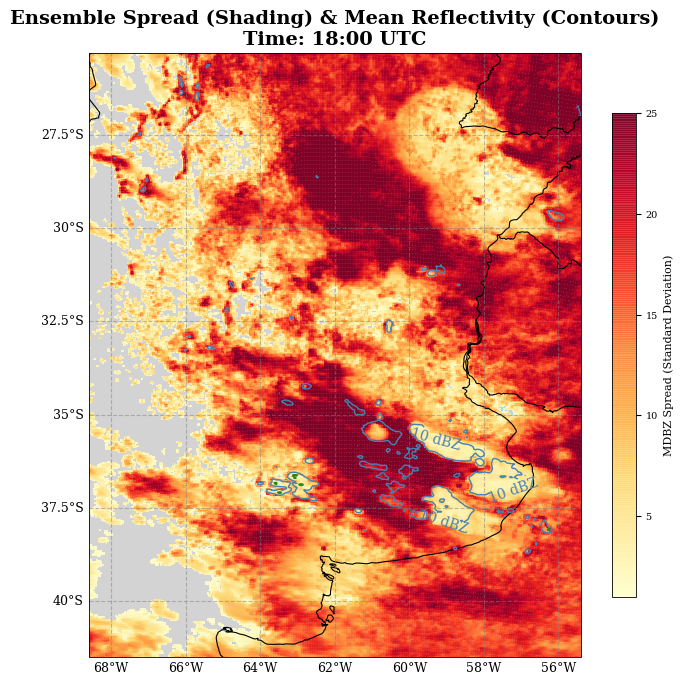

In [4]:
# --- Configuration ---
VAR_MDBZ = "MDBZ"     

TARGET_TIME = datetime(2024, 3, 19, 18, 0, 0)
NUM_MEMBERS = 60

def get_filepath(dt_obj, member_int):
    date_str = dt_obj.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{member_int:03d}.nc"

def setup_map(ax):
    """Adds Cartopy features and sets extent."""
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle='-', edgecolor='black')
    
    states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.5, linestyle=':')
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

print("Loading ensemble data...")
all_members_data = []
lat, lon = None, None

for m in range(1, NUM_MEMBERS + 1):
    filepath = get_filepath(TARGET_TIME, m)
    try:
        ds = xr.open_dataset(filepath)
        if lat is None:
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            
        data = ds[VAR_MDBZ].squeeze().values
        if data.ndim == 3:
            data = np.max(data, axis=0)
            
        all_members_data.append(data)
        ds.close()
    except FileNotFoundError:
        pass # Silently skip missing files for this step

# --- Statistical Calculations ---
ensemble_stack = np.stack(all_members_data)

# 1. Calculate Ensemble Mean
ensemble_mean = np.mean(ensemble_stack, axis=0)

# 2. Calculate Ensemble Spread (Standard Deviation)
ensemble_spread = np.std(ensemble_stack, axis=0)

# Mask out areas with near-zero spread so the basemap shows through
spread_masked = np.where(ensemble_spread > 1.0, ensemble_spread, np.nan)

# --- Plotting ---
print("Generating Spread/Mean Figure...")
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
setup_map(ax)

ax.set_title(f"Ensemble Spread (Shading) & Mean Reflectivity (Contours)\nTime: {TARGET_TIME.strftime('%H:%M')} UTC", 
             fontsize=14, fontweight='bold')

# 1. Plot Spread as Shading
# Using YlOrRd (Yellow to Red). vmin=1, vmax=25 is usually a good scale for dBZ standard deviation.
im = ax.pcolormesh(lon, lat, spread_masked, transform=ccrs.PlateCarree(),
                   cmap='YlOrRd', vmin=1, vmax=25, shading='auto', alpha=0.85)

cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, pad=0.04)
cbar.set_label(f"{VAR_MDBZ} Spread (Standard Deviation)")

# 2. Plot Mean as Contours
contour_levels = [10, 40]
# Use different line styles/widths to tell them apart without a legend
line_widths = [1.0, 1.5] 
colors = ['SteelBlue', 'ForestGreen']
contours = ax.contour(lon, lat, ensemble_mean, levels=contour_levels, 
                      colors=colors, linewidths=line_widths, transform=ccrs.PlateCarree())

# Add inline labels to the contour lines so you know which is 10, 20, and 40
ax.clabel(contours, inline=True, fontsize=10, fmt='%1.0f dBZ')
#save_fig(fig, "WRF_Spread_and_Mean")

plt.show()

Generating Sequence A (Spatial Expansion)...


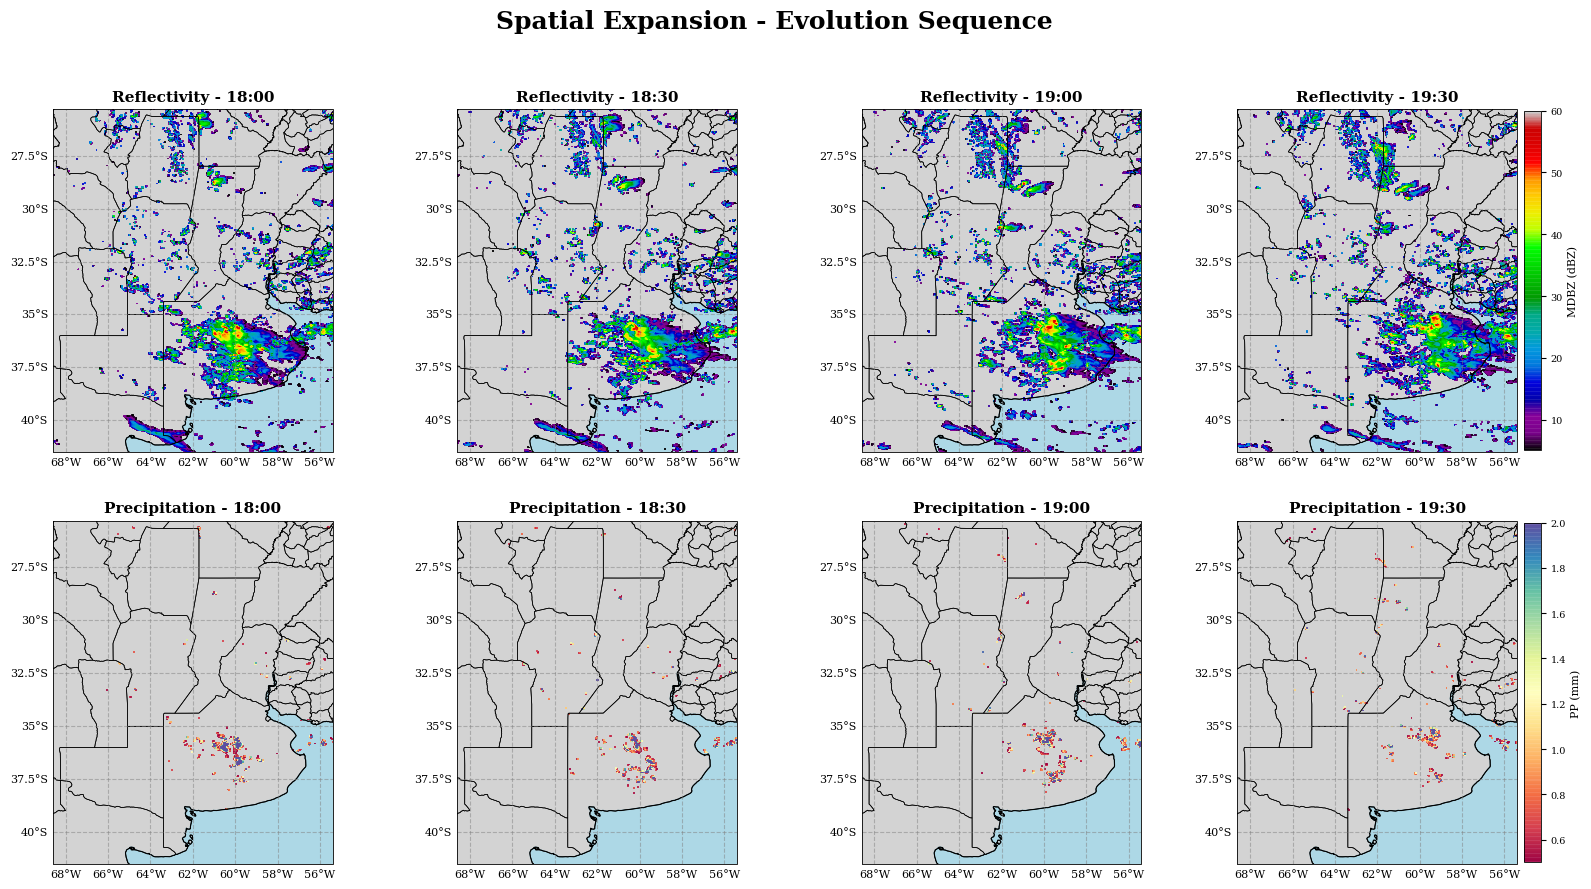

Generating Sequence B (Localized Intensification)...


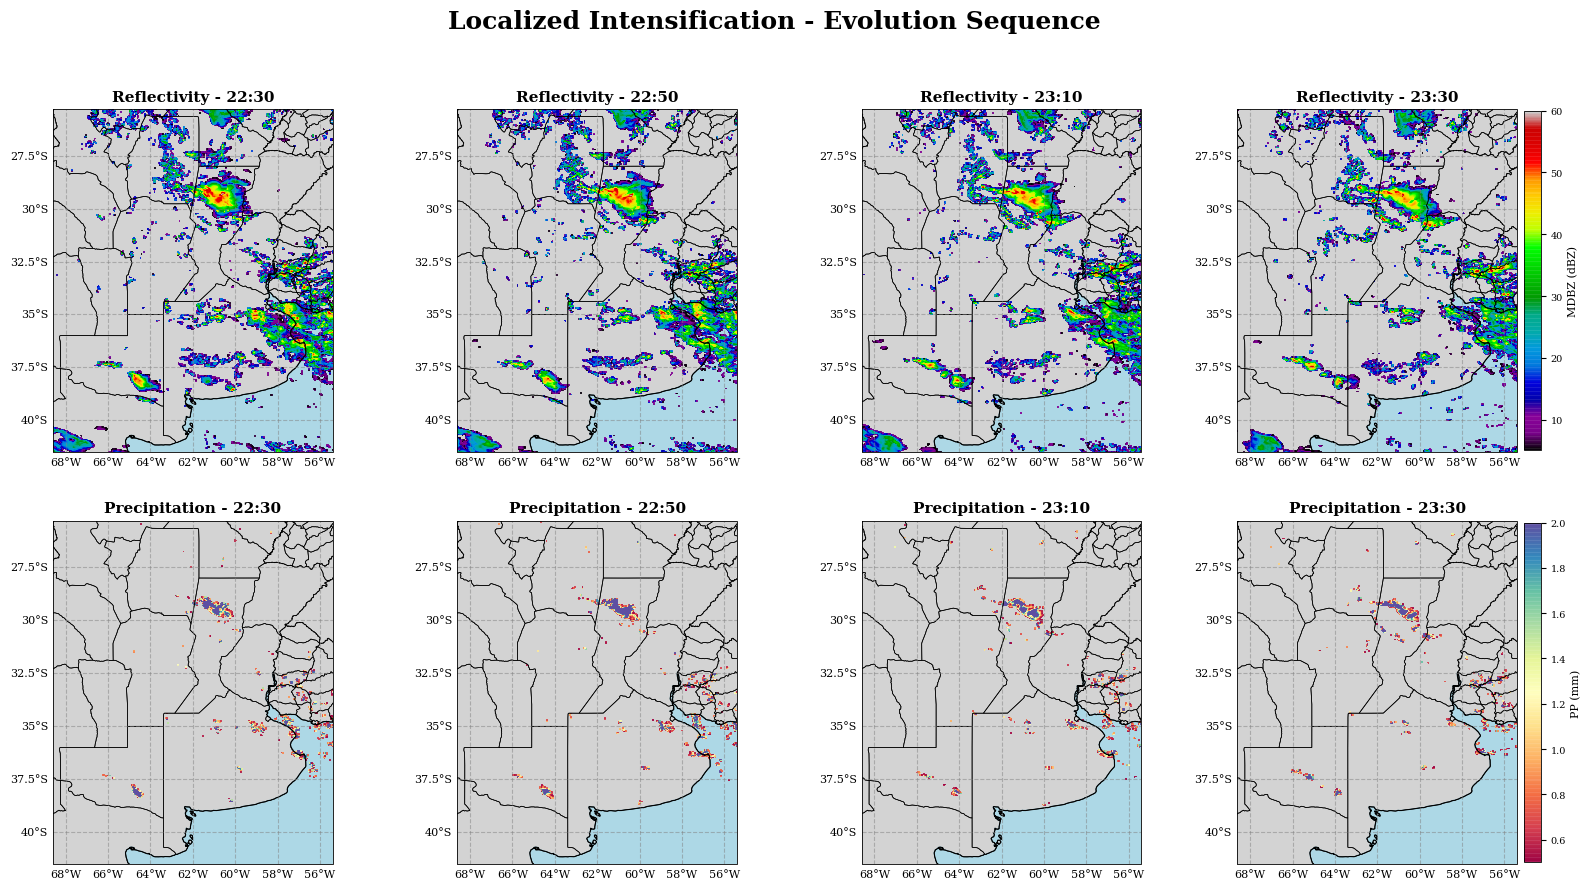

In [5]:
# --- Configuration ---
MEMBER = 1
VAR_MDBZ = "MDBZ"     
VAR_PP = "PP"     

def plot_spatial_panel(ax, lon, lat, data, title, cmap, vmin, vmax):
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle=':', edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
    
    # Mask values below or equal to zero
    data_masked = np.where(data > vmin, data, np.nan)
    
    # Plot the data with transparency (alpha)
    im = ax.pcolormesh(lon, lat, data_masked, transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax, shading='auto', alpha=0.9)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    #gl.xlabel_style = {'size': 9}
    #gl.ylabel_style = {'size': 9}
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    return im

def generate_sequence_figure(times, title_prefix, figname):
    """Generates a multi-panel sequence based on a list of times."""
    n_panels = len(times)
    
    # Create subplots dynamically with the PlateCarree projection attached to each axis
    fig, axes = plt.subplots(2, n_panels, figsize=(5 * n_panels, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    fig.suptitle(f"{title_prefix} - Evolution Sequence", fontsize=18, fontweight='bold')
    
    im_mdbz, im_pp = None, None
    
    for col, t in enumerate(times):
        filepath = get_filepath(t, MEMBER)
        
        # Handle 1D axes arrays properly for dynamic sizing
        ax_mdbz = axes[0, col] if n_panels > 1 else axes[0]
        ax_pp = axes[1, col] if n_panels > 1 else axes[1]
        
        try:
            ds = xr.open_dataset(filepath)
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            
            data_mdbz = ds[VAR_MDBZ].squeeze().values
            data_pp = ds[VAR_PP].squeeze().values
            
            if data_mdbz.ndim == 3:
                data_mdbz = np.max(data_mdbz, axis=0)
                
            # Plot Top Row (MDBZ)
            im_mdbz = plot_spatial_panel(ax_mdbz, lon, lat, data_mdbz, 
                                         f"Reflectivity - {t.strftime('%H:%M')}", 
                                         cmap='nipy_spectral', vmin=5, vmax=60) # Raised vmin slightly to hide noise
            
            # Plot Bottom Row (PP) - for spectral precipitation
            im_pp = plot_spatial_panel(ax_pp, lon, lat, data_pp, 
                                       f"Precipitation - {t.strftime('%H:%M')}", 
                                       cmap='Spectral', vmin=0.5, vmax=2)
            ds.close()
            
        except FileNotFoundError:
            for ax in [ax_mdbz, ax_pp]:
                ax.text(0.5, 0.5, f"Missing File:\n{t.strftime('%H:%M')}", 
                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Add shared colorbars at the bottom of the figure
    if im_mdbz:
        fig.colorbar(im_mdbz, ax=axes[0, -1], orientation='vertical', shrink=0.99, pad=0.02, label=f"{VAR_MDBZ} (dBZ)")
    if im_pp:
        fig.colorbar(im_pp, ax=axes[1, -1], orientation='vertical', shrink=0.99, pad=0.02, label=f"{VAR_PP} (mm)")
        
    #plt.tight_layout()
    #save_fig(fig, figname)
    plt.show()

# --- Execution ---

times_A = [
    datetime(2024, 3, 19, 18, 0, 0),
    datetime(2024, 3, 19, 18, 30, 0),
    datetime(2024, 3, 19, 19, 0, 0),
    datetime(2024, 3, 19, 19, 30, 0)
]
print("Generating Sequence A (Spatial Expansion)...")
generate_sequence_figure(times_A, "Spatial Expansion", "WRF_Sequence_A")


times_B = [
    datetime(2024, 3, 19, 22, 30, 0),
    datetime(2024, 3, 19, 22, 50, 0),
    datetime(2024, 3, 19, 23, 10, 0),
    datetime(2024, 3, 19, 23, 30, 0)
]
print("Generating Sequence B (Localized Intensification)...")
generate_sequence_figure(times_B, "Localized Intensification", "WRF_Sequence_B")

# PATOLOGIC POINTS

defined as points where the analisys is worse than the prior

In [6]:
base_path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data"
ref_base = np.load(f"{base_path}/WS_diag1800_MO_L0.1_Ne59/WS_diag1800_MO_L0.1_Ne59_multi_obs_ref_Ne059_tm00.npz",allow_pickle=True)

NTEMPS = [1, 2]
LOC_SCALES = [0.1, 2.0]
nens = [59]
# compare if ix,iy and iz are the same for all ref dataset
for nt in NTEMPS:
    for loc in LOC_SCALES:
        for nen in nens:
            dataset = f"WS_diag1800_MO_L{loc}_Ne{nen}/WS_diag1800_MO_L{loc}_Ne{nen}_multi_obs_ref_Ne0{nen}_tm00.npz"
            ref = np.load(f"{base_path}/{dataset}",allow_pickle=True)
            if not np.array_equal(ref['ix'], ref_base['ix']):
                print(f"ix mismatch for Nt{nt}, L{loc}, Ne{nen}")
            if not np.array_equal(ref['iy'], ref_base['iy']):
                print(f"iy mismatch for Nt{nt}, L{loc}, Ne{nen}")
            if not np.array_equal(ref['iz'], ref_base['iz']):
                print(f"iz mismatch for Nt{nt}, L{loc}, Ne{nen}")
            else:
                print(f"ix, iy, iz match for Nt{nt}, L{loc}, Ne{nen}")

ix, iy, iz match for Nt1, L0.1, Ne59
ix, iy, iz match for Nt1, L2.0, Ne59
ix, iy, iz match for Nt2, L0.1, Ne59
ix, iy, iz match for Nt2, L2.0, Ne59


In [7]:
# original dataset (prior conditions for the full 60 ensemble members) that contains the lat and lon coordinates
orig_dataset = np.load(f"{base_path}/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz",allow_pickle=True)

#Reference dataset containig the common thing for all the different methods, in this case also is comon to the different localizations index. containig mainly the obserbationns information
ref = np.load(f"{base_path}/WS_diag1800_MO_L0.1_Ne59/WS_diag1800_MO_L0.1_Ne59_multi_obs_ref_Ne059_tm00.npz",allow_pickle=True)

# Load the different datasets for different localization scales and number of Tempering steps
nt1_L01 = np.load(f"{base_path}/WS_diag1800_MO_L0.1_Ne59/WS_diag1800_MO_L0.1_Ne59_multi_obs_TEnKF_Nt01_as1.0_Lx0.1Ly0.1Lz0.1_Ne059_tm00.npz",allow_pickle=True)
nt2_L01 = np.load(f"{base_path}/WS_diag1800_MO_L0.1_Ne59/WS_diag1800_MO_L0.1_Ne59_multi_obs_TEnKF_Nt02_as1.0_Lx0.1Ly0.1Lz0.1_Ne059_tm00.npz",allow_pickle=True)
nt1_L2 = np.load(f"{base_path}/WS_diag1800_MO_L2.0_Ne59/WS_diag1800_MO_L2.0_Ne59_multi_obs_TEnKF_Nt01_as1.0_Lx2.0Ly2.0Lz2.0_Ne059_tm00.npz",allow_pickle=True)
nt2_L2 = np.load(f"{base_path}/WS_diag1800_MO_L2.0_Ne59/WS_diag1800_MO_L2.0_Ne59_multi_obs_TEnKF_Nt02_as1.0_Lx2.0Ly2.0Lz2.0_Ne059_tm00.npz",allow_pickle=True)

# Load lat and lon from the original dataset
lats = orig_dataset['lats']
lons = orig_dataset['lons']
ix = ref['ix']
iy = ref['iy']
iz = ref['iz']

# metric from the methods datasets
# err_hxf_field is the forecast error field or innovations field
# residual_field is the difference between the analysis and the observation
# abs_err_f_field should be equal to the absolute value of err_hxf_field


error_f = nt1_L01['err_hxf_field'] # all dataset share the same error_f_field, so we can use any of them to check if they are equal
# --- check that the prior error is really the same in all four ---
print("same err_f nt2_L01:", np.allclose(nt2_L01['err_hxf_field'], error_f, equal_nan=True))
print("same err_f nt1_L2: ", np.allclose(nt1_L2['err_hxf_field'],  error_f, equal_nan=True))
print("same err_f nt2_L2: ", np.allclose(nt2_L2['err_hxf_field'],  error_f, equal_nan=True))

error_a_nt1_L01 = nt1_L01['residual_field']
error_a_nt2_L01 = nt2_L01['residual_field']
error_a_nt1_L2 = nt1_L2['residual_field']
error_a_nt2_L2 = nt2_L2['residual_field']


same err_f nt2_L01: True
same err_f nt1_L2:  True
same err_f nt2_L2:  True


In [8]:

# --- absolute errors ---
abs_f        = np.abs(error_f)
abs_nt1_L01  = np.abs(error_a_nt1_L01)
abs_nt2_L01  = np.abs(error_a_nt2_L01)
abs_nt1_L2   = np.abs(error_a_nt1_L2)
abs_nt2_L2   = np.abs(error_a_nt2_L2)

# --- valid points (the grid is mostly NaN, only obs points are filled) ---
valid_L01 = np.isfinite(abs_f) & np.isfinite(abs_nt1_L01) & np.isfinite(abs_nt2_L01)
valid_L2  = np.isfinite(abs_f) & np.isfinite(abs_nt1_L2)  & np.isfinite(abs_nt2_L2)

print("n valid L0.1:", valid_L01.sum(), " n obs:", ref['ix'].size)
print("n valid L2.0:", valid_L2.sum())

# --- L = 0.1 ---
cond1_L01 = valid_L01 & (abs_nt1_L01 > abs_f)
cond2_L01 = valid_L01 & (abs_nt2_L01 > abs_f)
cond3_L01 = valid_L01 & (abs_nt2_L01 > abs_nt1_L01) & (abs_nt2_L01 > abs_f)

# --- L = 2.0 ---
cond1_L2 = valid_L2 & (abs_nt1_L2 > abs_f)
cond2_L2 = valid_L2 & (abs_nt2_L2 > abs_f)
cond3_L2 = valid_L2 & (abs_nt2_L2 > abs_nt1_L2) & (abs_nt2_L2 > abs_f)

print(f"L0.1  cond1 (nt1 worse than prior) | total {cond1_L01.sum():7}: | Percentage {100*cond1_L01.sum()/valid_L01.sum():4.1f}%")
print(f"L0.1  cond2 (nt2 worse than prior) | total {cond2_L01.sum():7}: | Percentage {100*cond2_L01.sum()/valid_L01.sum():4.1f}%")
print(f"L0.1  cond3 (nt2 worse than both)  | total {cond3_L01.sum():7}: | Percentage {100*cond3_L01.sum()/valid_L01.sum():4.1f}%")

print(f"L2.0  cond1 (nt1 worse than prior) | total {cond1_L2.sum():7}: | Percentage {100*cond1_L2.sum()/valid_L2.sum():4.1f}%")
print(f"L2.0  cond2 (nt2 worse than prior) | total {cond2_L2.sum():7}: | Percentage {100*cond2_L2.sum()/valid_L2.sum():4.1f}%")
print(f"L2.0  cond3 (nt2 worse than both)  | total {cond3_L2.sum():7}: | Percentage {100*cond3_L2.sum()/valid_L2.sum():4.1f}%")

n valid L0.1: 5511924  n obs: 693783
n valid L2.0: 5511924
L0.1  cond1 (nt1 worse than prior) | total  180042: | Percentage  3.3%
L0.1  cond2 (nt2 worse than prior) | total  115770: | Percentage  2.1%
L0.1  cond3 (nt2 worse than both)  | total   91203: | Percentage  1.7%
L2.0  cond1 (nt1 worse than prior) | total 1250143: | Percentage 22.7%
L2.0  cond2 (nt2 worse than prior) | total  494540: | Percentage  9.0%
L2.0  cond3 (nt2 worse than both)  | total  286741: | Percentage  5.2%


In [9]:
# masks are (x, y, z) = (558, 898, 11); lats/lons are (y, x) = (898, 558)
# collapse z and transpose -> (898, 558), same shape as lats/lons

valid_2d      = valid_L01.any(axis=2).T

cond1_L01_2d  = cond1_L01.any(axis=2).T
cond2_L01_2d  = cond2_L01.any(axis=2).T
cond3_L01_2d  = cond3_L01.any(axis=2).T

cond1_L2_2d   = cond1_L2.any(axis=2).T
cond2_L2_2d   = cond2_L2.any(axis=2).T
cond3_L2_2d   = cond3_L2.any(axis=2).T

# how many levels are flagged in each column (0 to 11), useful as color
n1_L01 = cond1_L01.sum(axis=2).T
n2_L01 = cond2_L01.sum(axis=2).T
n3_L01 = cond3_L01.sum(axis=2).T

n1_L2  = cond1_L2.sum(axis=2).T
n2_L2  = cond2_L2.sum(axis=2).T
n3_L2  = cond3_L2.sum(axis=2).T

print("columns with valid obs :", valid_2d.sum())
print("L0.1 cond1 columns:", cond1_L01_2d.sum(), " cond2:", cond2_L01_2d.sum(), " cond3:", cond3_L01_2d.sum())
print("L2.0 cond1 columns:", cond1_L2_2d.sum(),  " cond2:", cond2_L2_2d.sum(),  " cond3:", cond3_L2_2d.sum())

columns with valid obs : 501084
L0.1 cond1 columns: 70718  cond2: 62929  cond3: 56611
L2.0 cond1 columns: 268927  cond2: 209604  cond3: 148183


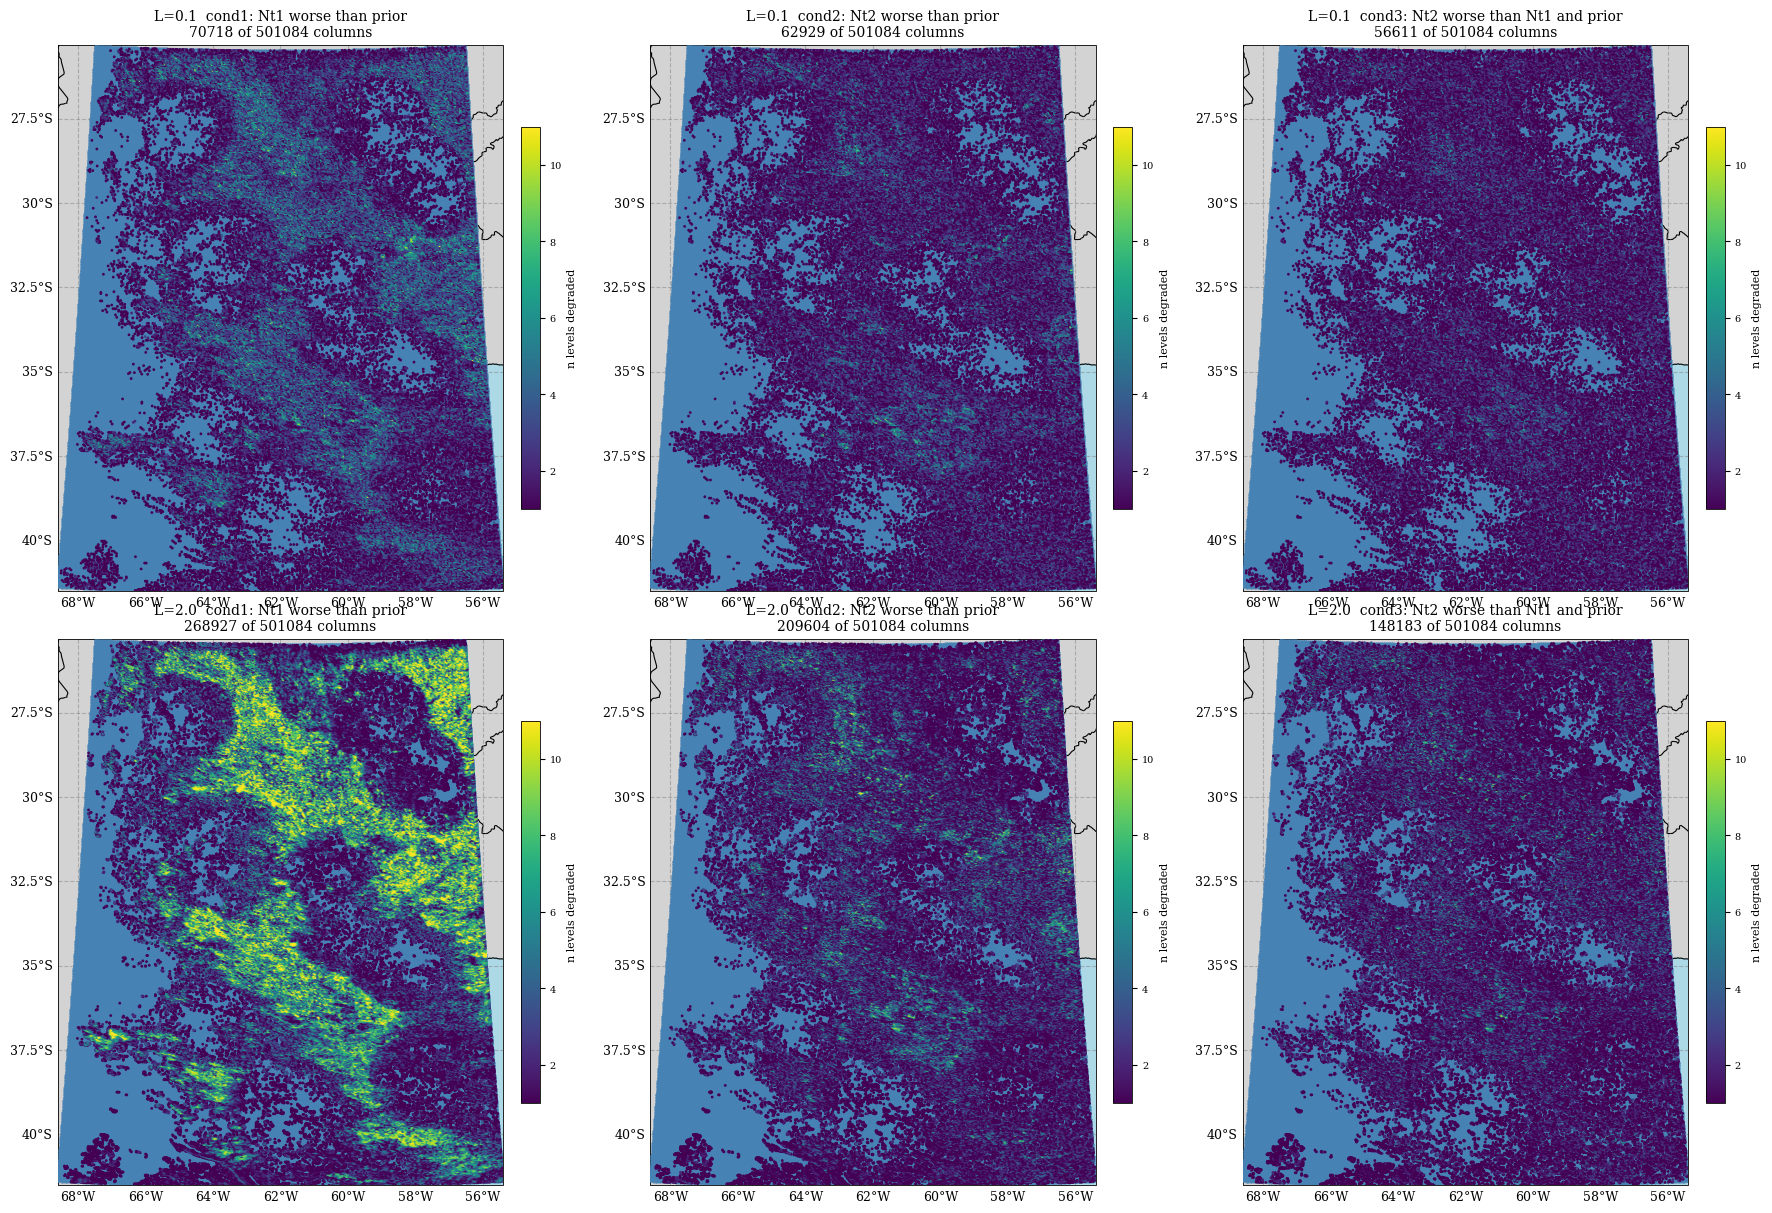

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})

panels = [
    (cond1_L01_2d, n1_L01, "L=0.1  cond1: Nt1 worse than prior"),
    (cond2_L01_2d, n2_L01, "L=0.1  cond2: Nt2 worse than prior"),
    (cond3_L01_2d, n3_L01, "L=0.1  cond3: Nt2 worse than Nt1 and prior"),
    (cond1_L2_2d,  n1_L2,  "L=2.0  cond1: Nt1 worse than prior"),
    (cond2_L2_2d,  n2_L2,  "L=2.0  cond2: Nt2 worse than prior"),
    (cond3_L2_2d,  n3_L2,  "L=2.0  cond3: Nt2 worse than Nt1 and prior"),
]

for ax, (mask_2d, nlev, title) in zip(axes.flat, panels):
    setup_map(ax)

    # all observed columns in light gray, as reference
    ax.scatter(lons[valid_2d], lats[valid_2d], s=0.1, c='steelblue',
               transform=ccrs.PlateCarree(), zorder=3)

    # flagged columns, colored by how many levels are degraded
    sc = ax.scatter(lons[mask_2d], lats[mask_2d], s=1, c=nlev[mask_2d],
                    cmap='viridis', vmin=1, vmax=11,
                    transform=ccrs.PlateCarree(), zorder=4)

    ax.set_title(f"{title}\n{mask_2d.sum()} of {valid_2d.sum()} columns", fontsize=10)
    fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.03,
                 label='n levels degraded')

plt.tight_layout()
plt.show()

In [14]:
ix = ref['ix']
iy = ref['iy']
iz = ref['iz']

# --- extract only the observed points: (558,898,11) -> (693783,) ---
abs_f_obs       = np.abs(error_f[ix, iy, iz])
abs_nt1_L01_obs = np.abs(error_a_nt1_L01[ix, iy, iz])
abs_nt2_L01_obs = np.abs(error_a_nt2_L01[ix, iy, iz])
abs_nt1_L2_obs  = np.abs(error_a_nt1_L2[ix, iy, iz])
abs_nt2_L2_obs  = np.abs(error_a_nt2_L2[ix, iy, iz])

print("shape abs_f_obs:", abs_f_obs.shape)
print("any NaN in abs_f_obs      :", np.isnan(abs_f_obs).sum())
print("any NaN in abs_nt1_L01_obs:", np.isnan(abs_nt1_L01_obs).sum())
print("any NaN in abs_nt2_L01_obs:", np.isnan(abs_nt2_L01_obs).sum())
print("any NaN in abs_nt1_L2_obs :", np.isnan(abs_nt1_L2_obs).sum())
print("any NaN in abs_nt2_L2_obs :", np.isnan(abs_nt2_L2_obs).sum())

# --- conditions, now 1D of length 693783 ---
cond1_L01 = abs_nt1_L01_obs > abs_f_obs
cond2_L01 = abs_nt2_L01_obs > abs_f_obs
cond3_L01 = (abs_nt2_L01_obs > abs_nt1_L01_obs) & (abs_nt2_L01_obs > abs_f_obs)

cond1_L2 = abs_nt1_L2_obs > abs_f_obs
cond2_L2 = abs_nt2_L2_obs > abs_f_obs
cond3_L2 = (abs_nt2_L2_obs > abs_nt1_L2_obs) & (abs_nt2_L2_obs > abs_f_obs)

n_obs = ix.size
print("L0.1 cond1:", cond1_L01.sum(), 100*cond1_L01.sum()/n_obs)
print("L0.1 cond2:", cond2_L01.sum(), 100*cond2_L01.sum()/n_obs)
print("L0.1 cond3:", cond3_L01.sum(), 100*cond3_L01.sum()/n_obs)
print("L2.0 cond1:", cond1_L2.sum(),  100*cond1_L2.sum()/n_obs)
print("L2.0 cond2:", cond2_L2.sum(),  100*cond2_L2.sum()/n_obs)
print("L2.0 cond3:", cond3_L2.sum(),  100*cond3_L2.sum()/n_obs)

# --- coordinates of every observation: lats/lons are (898,558) = (y,x) ---
obs_lat = lats[iy, ix]
obs_lon = lons[iy, ix]
print("obs_lat range:", obs_lat.min(), obs_lat.max())
print("obs_lon range:", obs_lon.min(), obs_lon.max())

shape abs_f_obs: (693783,)
any NaN in abs_f_obs      : 0
any NaN in abs_nt1_L01_obs: 0
any NaN in abs_nt2_L01_obs: 0
any NaN in abs_nt1_L2_obs : 0
any NaN in abs_nt2_L2_obs : 0
L0.1 cond1: 179874 25.926550520840088
L0.1 cond2: 115655 16.670198030219822
L0.1 cond3: 91165 13.140275849941553
L2.0 cond1: 296437 42.727625208458555
L2.0 cond2: 112313 16.188491214111618
L2.0 cond3: 66497 9.584697232419936
obs_lat range: -41.549904 -25.35463
obs_lon range: -68.56079 -55.418213


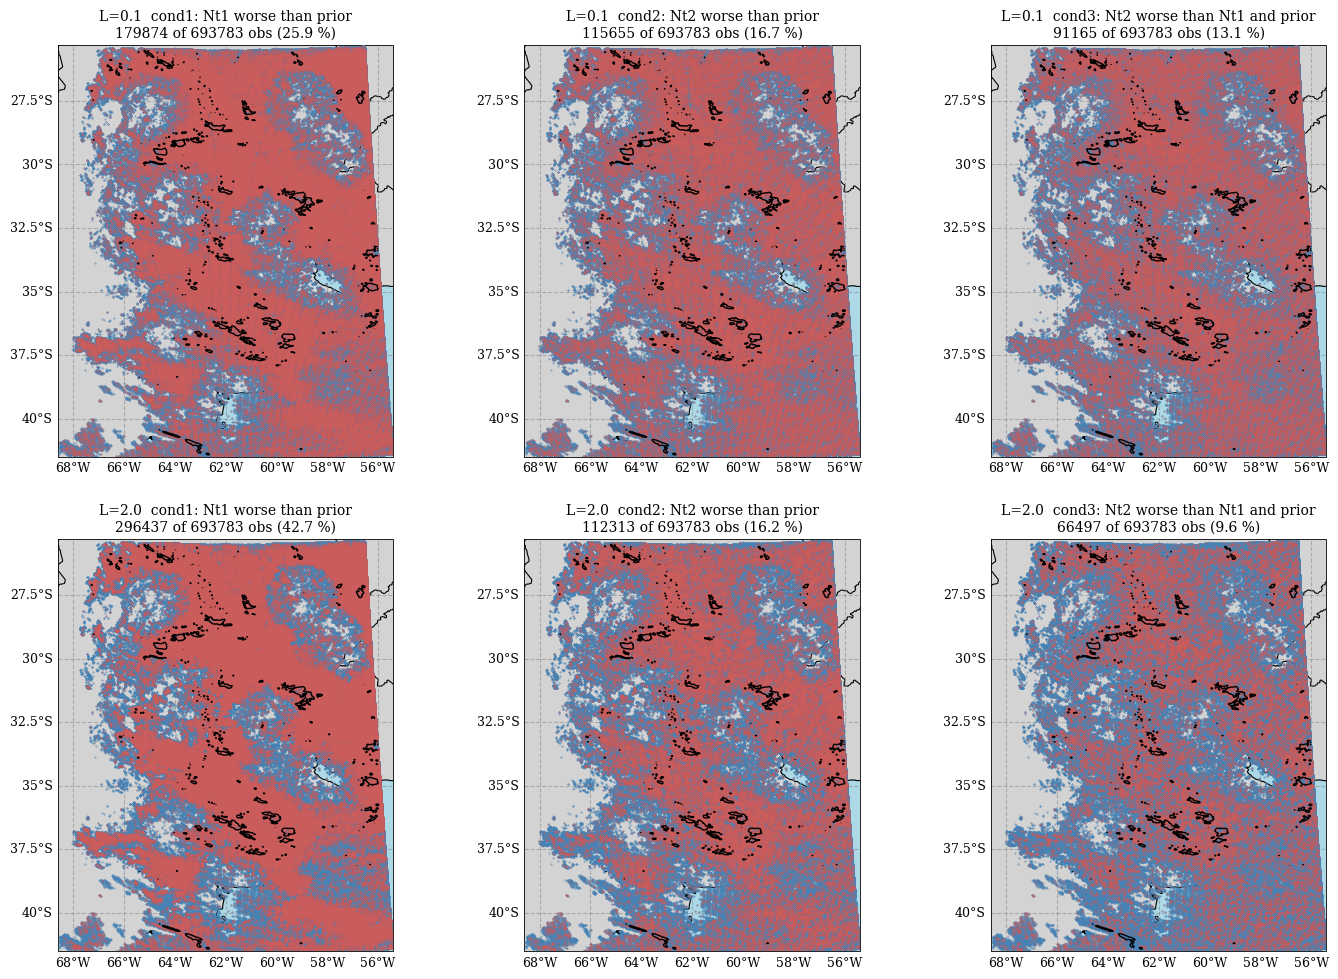

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()},gridspec_kw={'wspace': 0.01, 'hspace': 0.2})

panels = [
    (cond1_L01, "L=0.1  cond1: Nt1 worse than prior"),
    (cond2_L01, "L=0.1  cond2: Nt2 worse than prior"),
    (cond3_L01, "L=0.1  cond3: Nt2 worse than Nt1 and prior"),
    (cond1_L2,  "L=2.0  cond1: Nt1 worse than prior"),
    (cond2_L2,  "L=2.0  cond2: Nt2 worse than prior"),
    (cond3_L2,  "L=2.0  cond3: Nt2 worse than Nt1 and prior"),
]
contour_levels = [40]
line_widths = [1.0] 
colors = ['Black']
mdbz_truth = np.nanmax(ref['truth_hx'],axis=2)
for ax, (cond, title) in zip(axes.flat, panels):
    setup_map(ax)
    ax.scatter(obs_lon, obs_lat, s=0.1, c='steelblue',
               transform=ccrs.PlateCarree(), zorder=3)
    ax.scatter(obs_lon[cond], obs_lat[cond], s=0.05, c='IndianRed',
               transform=ccrs.PlateCarree(), zorder=4)
    ax.set_title(f"{title}\n{cond.sum()} of {n_obs} obs "
                 f"({100*cond.sum()/n_obs:.1f} %)", fontsize=10)

    contours = ax.contour(lons, lats, mdbz_truth.T, levels=contour_levels, 
                        colors=colors, linewidths=line_widths, transform=ccrs.PlateCarree(),zorder=10)

    ax.clabel(contours, inline=True, fontsize=10, fmt='%1.0f dBZ',zorder=10)

plt.tight_layout()
plt.show()

In [43]:
np.shape(np.nanmax(ref['truth_hx'],axis=2))

(558, 898)

In [38]:
print(list(ref.keys()))

['truth', 'xf_mean', 'truth_hx', 'yo', 'yo_clean', 'ix', 'iy', 'iz', 'var_names']


In [ ]:
#print available keys in the datasets
print("Keys in orig_dataset:", orig_dataset.keys())
print("Keys in ref dataset:", ref.keys())
print("Keys in nt1 dataset:", nt1.keys())

#shape of orig dataset lats and lons and, ix,iy from ref dataset
print("Shape of orig_dataset lats:", orig_dataset['lats'].shape)
print("Shape of orig_dataset lons:", orig_dataset['lons'].shape)
print("Shape of ref dataset ix:", ref['ix'].shape)
print("Shape of ref dataset iy:", ref['iy'].shape)
print("Shape of ref dataset iz:", ref['iz'].shape)
print("Shape of ref dataset yo:", ref['yo'].shape)
# number of unique values from ix,iy,iz
print("Number of unique values in ref dataset ix:", len(np.unique(ref['ix'])))
print("Number of unique values in ref dataset iy:", len(np.unique(ref['iy'])))
print("Number of unique values in ref dataset iz:", len(np.unique(ref['iz'])))
# min and max values from ix,iy,iz
print("Min and Max values in ref dataset ix:", np.min(ref['ix']), np.max(ref['ix']))
print("Min and Max values in ref dataset iy:", np.min(ref['iy']), np.max(ref['iy']))
print("Min and Max values in ref dataset iz:", np.min(ref['iz']), np.max(ref['iz']))

# unique lats lons from unique ix and iy from ref dataset
unique_ix = ref['ix']
unique_iy = ref['iy']
unique_lats = orig_dataset['lats'][unique_iy]
unique_lons = orig_dataset['lons'][unique_ix]


# print the shapes, min and max of hxf_mean_field, err_hxf_field and residual_field and bias_f_field from nt1 dataset
print("Shape of nt1 dataset hxf_mean_field:", nt1['hxf_mean_field'].shape)
print("Shape of nt1 dataset err_hxf_field:", nt1['err_hxf_field'].shape)
print("Shape of nt1 dataset residual_field:", nt1['residual_field'].shape)
print("Shape of nt1 dataset bias_f_field:", nt1['bias_f_field'].shape)
# 
print("Min and Max values in nt1 dataset hxf_mean_field:", np.min(nt1['hxf_mean_field']), np.max(nt1['hxf_mean_field']))
print("Min and Max values in nt1 dataset err_hxf_field:", np.min(nt1['err_hxf_field']), np.max(nt1['err_hxf_field']))
print("Min and Max values in nt1 dataset residual_field:", np.min(nt1['residual_field']), np.max(nt1['residual_field']))
print("Min and Max values in nt1 dataset bias_f_field:", np.min(nt1['bias_f_field']), np.max(nt1['bias_f_field']))
# explore crps field and global from nt1 dataset
print("Shape of nt1 dataset crps_field:", nt1['crps_f_field'].shape)
print("Shape of nt1 dataset crps_global:", np.shape(nt1['crps_f_global_qg']))
print("Min and Max values in nt1 dataset crps_field:", np.nanmin(nt1['crps_f_field']), np.nanmax(nt1['crps_f_field']))
print("Min and Max values in nt1 dataset crps_global:", np.nanmin(nt1['crps_f_global_qg']), np.nanmax(nt1['crps_f_global_qg']))

###
base_path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data"
locs = [0.1, 2.0]
nens = [40,59]
# create a dataframe with the data for Nt01, Nt02
dataset = f"WS_diag1800_MO_L{loc}_Ne{nen}/WS_diag1800_MO_L{loc}_Ne{nen}_multi_obs_TEnKF_Nt01_as1.0_Lx{loc}Ly{loc}Lz{loc}_Ne0{nen}_tm00.npz"

In [ ]:
import numpy as np

datasets = {"nt1_L01": nt1_L01, "nt2_L01": nt2_L01,
            "nt1_L2":  nt1_L2,  "nt2_L2":  nt2_L2}

nx, ny, nz = error_f.shape          # (558, 898, 11)
n_obs = ref['ix'].size              # 693783

# --- structural checks --------------------------------------------------
for name, ds in datasets.items():
    ef, ra = ds['err_hxf_field'], ds['residual_field']
    print(f"{name:9s} finite(err_f)={np.isfinite(ef).sum():7d}  "
          f"finite(res)={np.isfinite(ra).sum():7d}  (n_obs={n_obs})")
    if 'abs_err_f_field' in ds:
        print(f"          |err_f| ok = "
              f"{np.allclose(ds['abs_err_f_field'], np.abs(ef), equal_nan=True)}")
    if 'abs_err_a_field' in ds:
        print(f"          |err_a| ok = "
              f"{np.allclose(ds['abs_err_a_field'], np.abs(ra), equal_nan=True)}")
    print(f"          shared prior = {np.allclose(ef, error_f, equal_nan=True)}")

# obs indices land on finite cells and nowhere else
ix, iy, iz = ref['ix'], ref['iy'], ref['iz']
assert np.isfinite(error_f[ix, iy, iz]).all()
assert np.isfinite(error_f).sum() == n_obs

In [ ]:
nt1['var_names']

In [ ]:
list(nt1.keys())

In [ ]:
np.nanmean(nt1['crps_f_field'][:,:,:,2])

In [ ]:
nt1['crps_f_global_qs']

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(unique_lons, unique_lats, c='blue', marker='o', label='Unique Points')
plt.title('Unique Lat/Lon Points from Ref Dataset')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(LON_MIN, LON_MAX)
plt.ylim(LAT_MIN, LAT_MAX)
plt.grid()
plt.legend()
plt.show()